# **1. Data Import & EDA**

In [ ]:
from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

!pip install kagglehub -q

import kagglehub
path = kagglehub.competition_download('GiveMeSomeCredit')
print("Path to dataset:", path)

import os
for f in os.listdir(path):
    print(f)

Saving kaggle.json to kaggle.json


100%|██████████| 5.16M/5.16M [00:00<00:00, 96.3MB/s]

Extracting files...


Path to dataset: /root/.cache/kagglehub/competitions/GiveMeSomeCredit
Data Dictionary.xls
sampleEntry.csv
cs-test.csv
cs-training.csv


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn - Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Sklearn - Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, silhouette_score, davies_bouldin_score
)

# Imbalanced
from imblearn.over_sampling import SMOTE

# SHAP
import shap

# Model saving
import pickle
import os


In [ ]:
import pandas as pd
import numpy as np
import os

import kagglehub
path = kagglehub.competition_download('GiveMeSomeCredit')

df_raw = pd.read_csv(os.path.join(path, 'cs-training.csv'), index_col=0)

print("Shape:", df_raw.shape)
df_raw

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [ ]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct}))

                                      Missing  Persen (%)
SeriousDlqin2yrs                            0        0.00
RevolvingUtilizationOfUnsecuredLines        0        0.00
age                                         0        0.00
NumberOfTime30-59DaysPastDueNotWorse        0        0.00
DebtRatio                                   0        0.00
MonthlyIncome                           29731       19.82
NumberOfOpenCreditLinesAndLoans             0        0.00
NumberOfTimes90DaysLate                     0        0.00
NumberRealEstateLoansOrLines                0        0.00
NumberOfTime60-89DaysPastDueNotWorse        0        0.00
NumberOfDependents                       3924        2.62


In [ ]:
df_raw.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Tidak Default (0): 139,974 (93.32%)
Default (1)      : 10,026 (6.68%)
Rasio imbalance  : 1 : 14.0


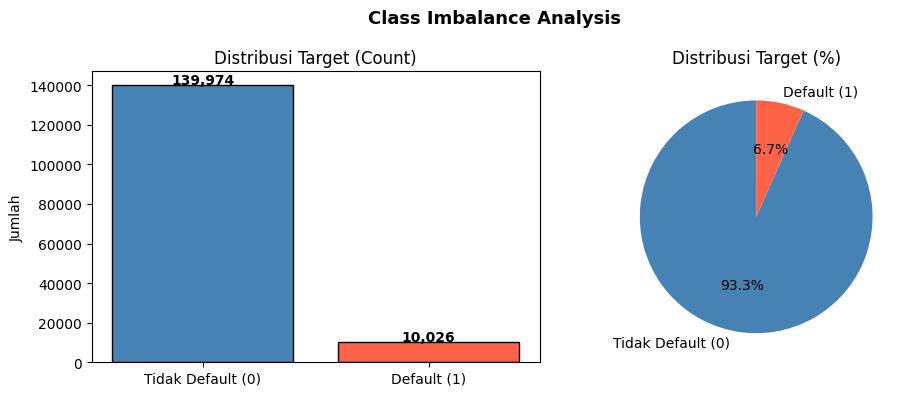

In [ ]:
# Distribusi target
target_counts = df_raw['SeriousDlqin2yrs'].value_counts()
target_pct = df_raw['SeriousDlqin2yrs'].value_counts(normalize=True).mul(100).round(2)

print(f"Tidak Default (0): {target_counts[0]:,} ({target_pct[0]}%)")
print(f"Default (1)      : {target_counts[1]:,} ({target_pct[1]}%)")
print(f"Rasio imbalance  : 1 : {round(target_counts[0]/target_counts[1], 1)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(['Tidak Default (0)', 'Default (1)'],
            target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribusi Target (Count)')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values,
            labels=['Tidak Default (0)', 'Default (1)'],
            colors=['steelblue', 'tomato'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribusi Target (%)')

plt.suptitle('Class Imbalance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_raw['MonthlyIncome'].fillna(df_raw['MonthlyIncome'].median(), inplace=True)
df_raw['NumberOfDependents'].fillna(df_raw['NumberOfDependents'].median(), inplace=True)

print(df_raw.isnull().sum())

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


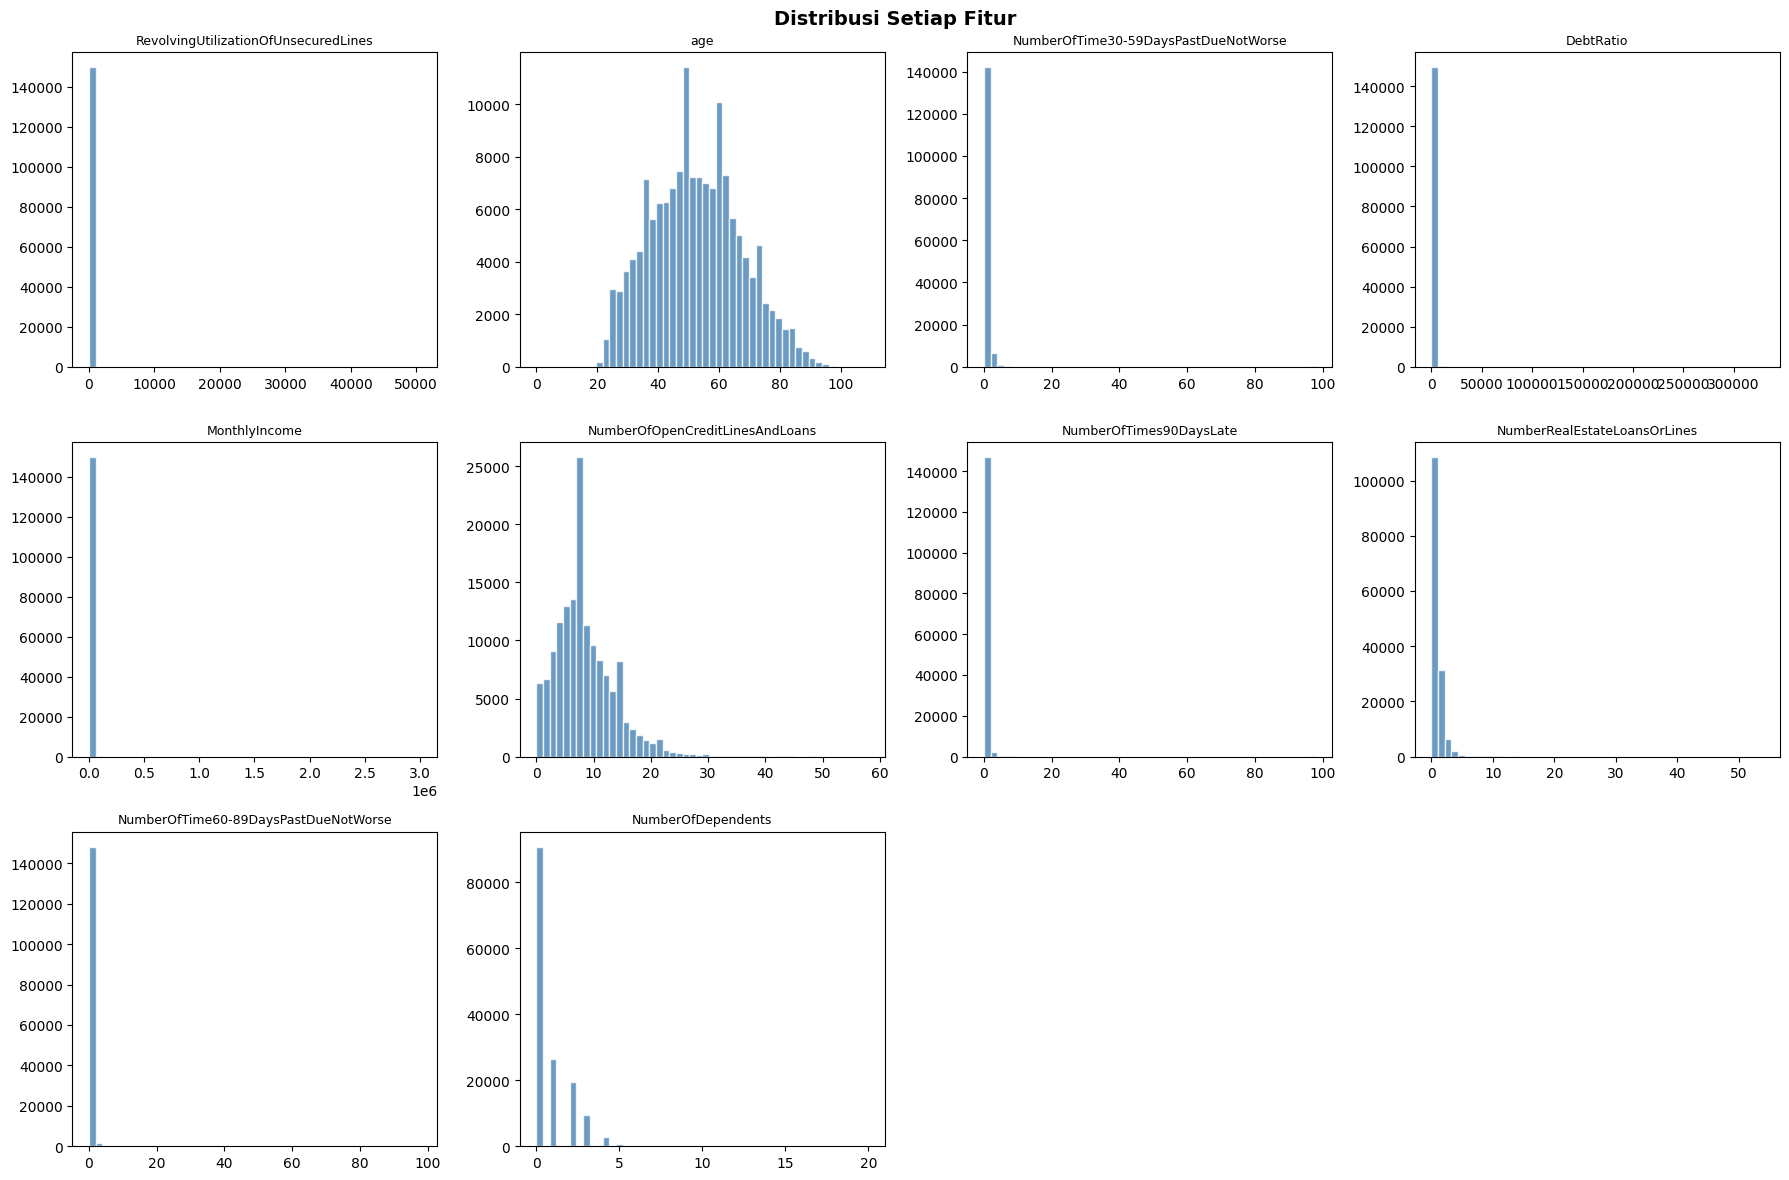

In [ ]:
# Distribusi semua fitur numerik
features = df_raw.drop('SeriousDlqin2yrs', axis=1).columns.tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_raw[col].dropna(), bins=50, color='steelblue',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# Sembunyikan subplot kosong
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

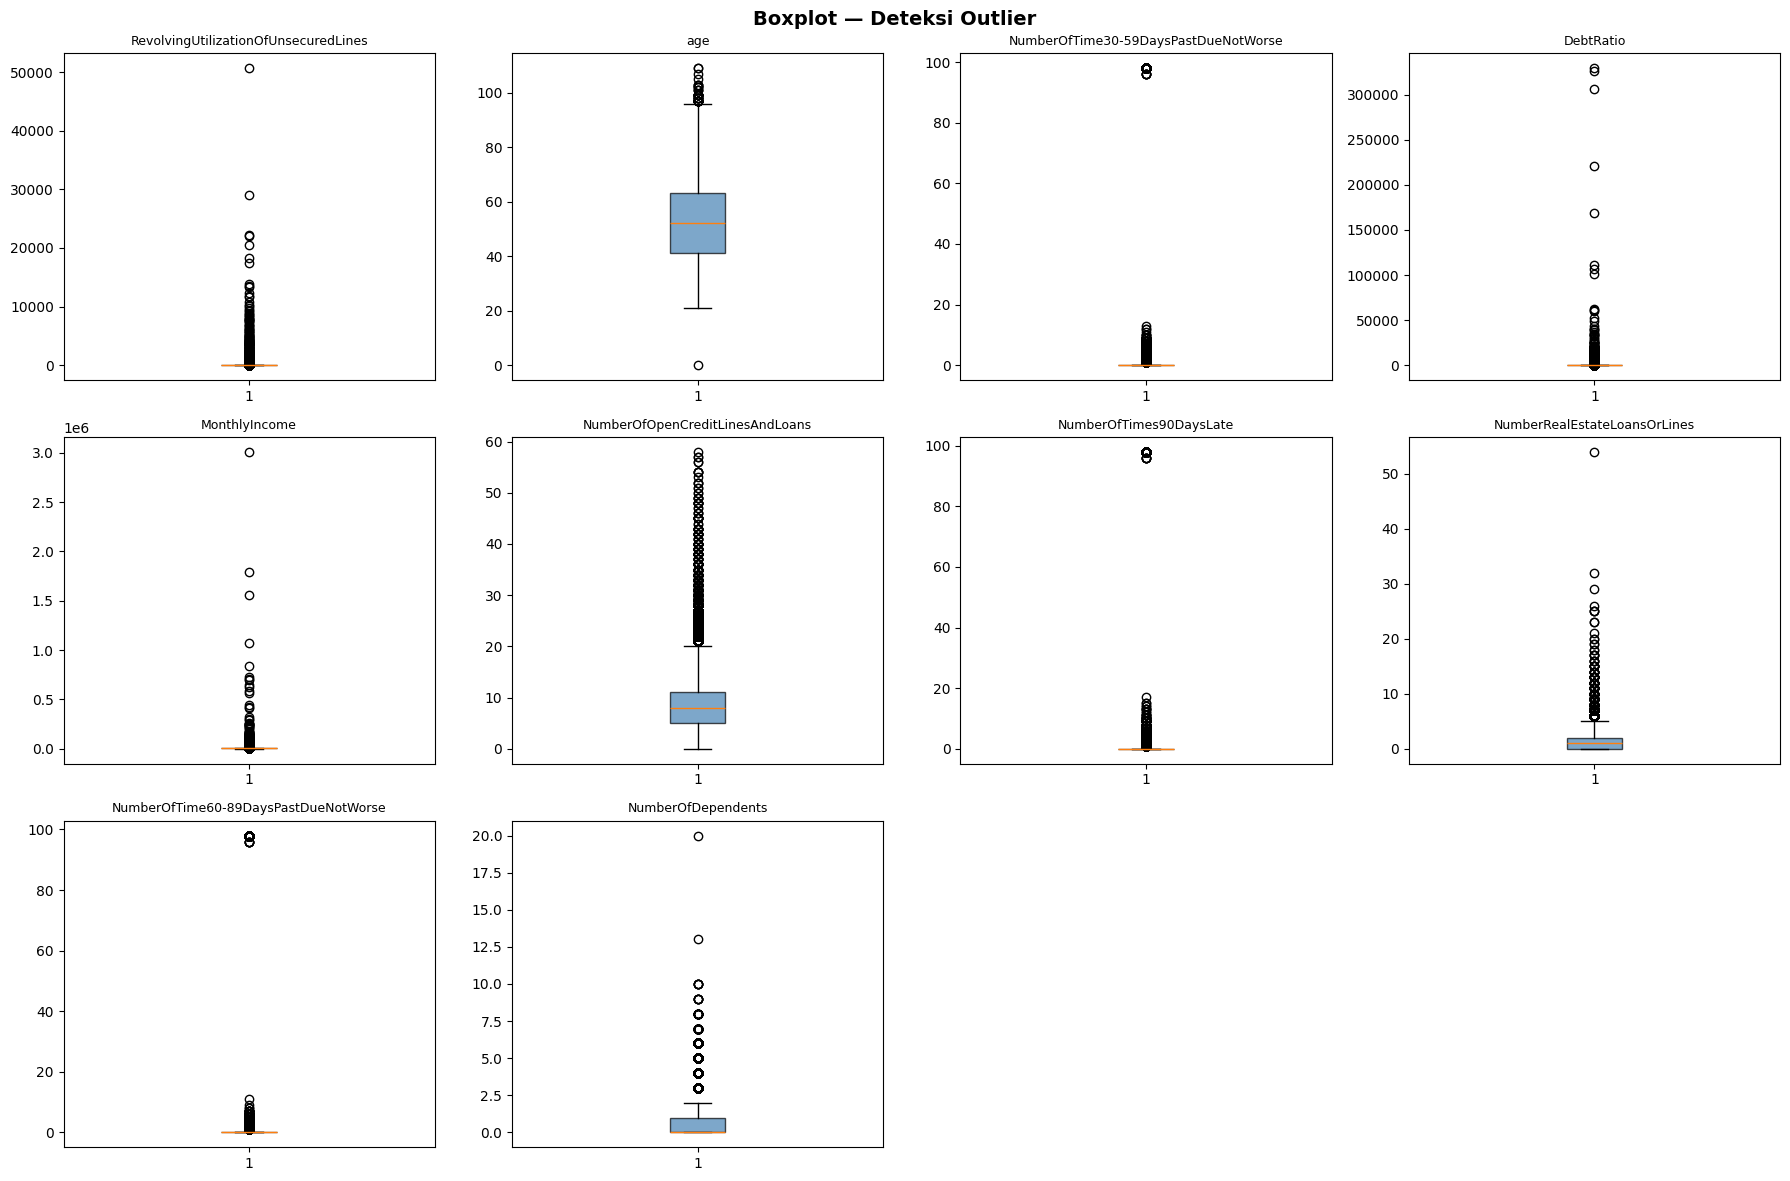

In [ ]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df_raw[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=9)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot — Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

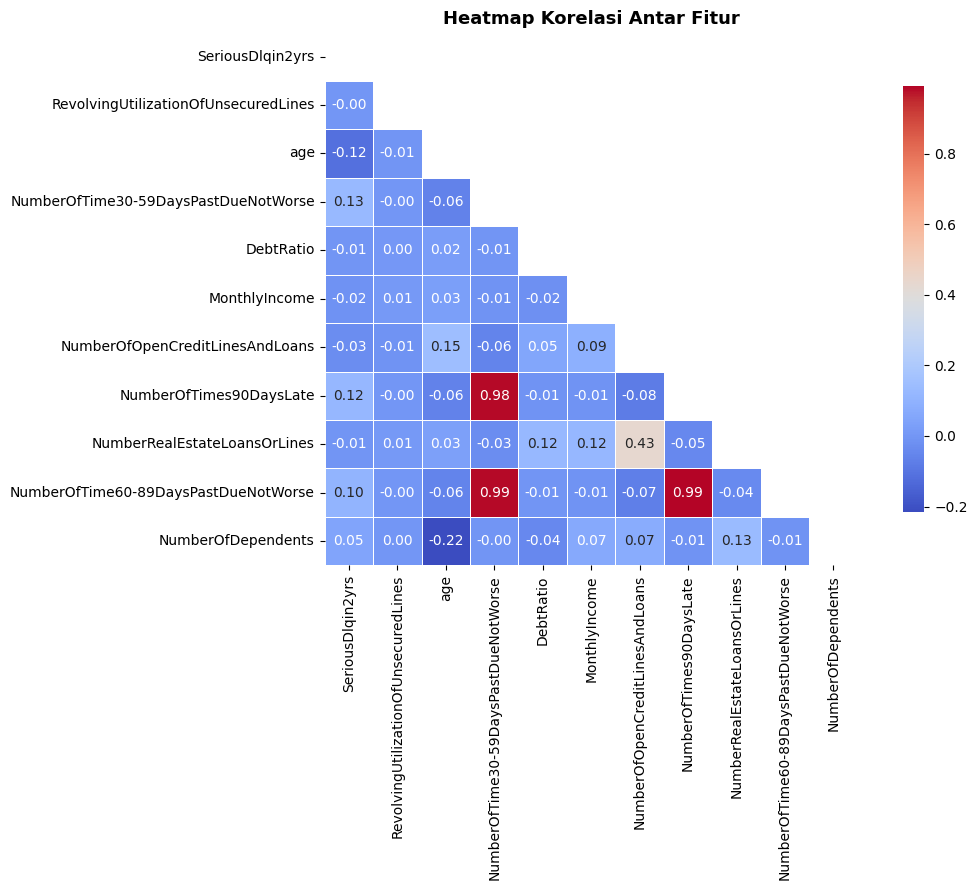

KORELASI TERHADAP TARGET
NumberOfTime30-59DaysPastDueNotWorse    0.1256
NumberOfTimes90DaysLate                 0.1172
NumberOfTime60-89DaysPastDueNotWorse    0.1023
NumberOfDependents                      0.0469
RevolvingUtilizationOfUnsecuredLines   -0.0018
NumberRealEstateLoansOrLines           -0.0070
DebtRatio                              -0.0076
MonthlyIncome                          -0.0172
NumberOfOpenCreditLinesAndLoans        -0.0297
age                                    -0.1154
Name: SeriousDlqin2yrs, dtype: float64


In [ ]:
# Heatmap korelasi
plt.figure(figsize=(12, 9))
corr_matrix = df_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi terhadap target
print("KORELASI TERHADAP TARGET")
corr_target = df_raw.corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values(ascending=False)
print(corr_target.round(4))

# **2. Data Preprocessing**

In [ ]:
df = df_raw.copy()
print(f"Shape awal: {df_raw.shape}")

Shape awal: (150000, 11)


In [ ]:
# Imputasi dengan median (robust terhadap outlier)
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print("Missing values setelah imputasi:")
print(df.isnull().sum())

Missing values setelah imputasi:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [ ]:
#TAHAP 1 — DOMAIN KNOWLEDGE CLIPPING

print(" SEBELUM DOMAIN CLIPPING ")
domain_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
print(df[domain_cols].describe().round(2))

# 1. RevolvingUtilizationOfUnsecuredLines
#    Definisi: rasio penggunaan kredit → HARUS antara 0–1
#    Nilai >1 = tidak masuk akal secara definisi
df['RevolvingUtilizationOfUnsecuredLines'] = \
    df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

# 2. DebtRatio
#    Definisi: rasio utang/pendapatan → wajar maksimal 10
#    Nilai 300.000 = jelas data error
df['DebtRatio'] = df['DebtRatio'].clip(0, 10)

# 3. age
#    Minimum usia pengajuan kredit = 18 tahun
#    Maksimum yang masuk akal = 100 tahun
df['age'] = df['age'].clip(18, 100)

# 4. Fitur keterlambatan
#    Dalam rentang 2 tahun, max keterlambatan yang masuk akal = 20x
#    Nilai 96, 98 = data error
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in late_cols:
    df[col] = df[col].clip(0, 20)

print(" SETELAH DOMAIN CLIPPING ")
print(df[domain_cols].describe().round(2))

 SEBELUM DOMAIN CLIPPING 
       RevolvingUtilizationOfUnsecuredLines  DebtRatio        age  \
count                             150000.00  150000.00  150000.00   
mean                                   6.05     353.01      52.30   
std                                  249.76    2037.82      14.77   
min                                    0.00       0.00       0.00   
25%                                    0.03       0.18      41.00   
50%                                    0.15       0.37      52.00   
75%                                    0.56       0.87      63.00   
max                                50708.00  329664.00     109.00   

       NumberOfTime30-59DaysPastDueNotWorse  \
count                             150000.00   
mean                                   0.42   
std                                    4.19   
min                                    0.00   
25%                                    0.00   
50%                                    0.00   
75%                    

In [ ]:
# TAHAP 2 — IQR CAPPING

def iqr_capping(df, columns, multiplier=3.0):

    df_capped = df.copy()
    summary = []

    for col in columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

        summary.append({
            'Fitur'          : col,
            'Q1'             : round(Q1, 2),
            'Q3'             : round(Q3, 2),
            'Batas Bawah'    : round(lower, 2),
            'Batas Atas'     : round(upper, 2),
            'Jumlah Ter-cap' : n_outlier
        })

    return df_capped, pd.DataFrame(summary)


# Fitur yang di-cap dengan IQR
# (tidak punya batas logis yang pasti dari domain knowledge)
iqr_cols = [
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

df, iqr_summary = iqr_capping(df, iqr_cols, multiplier=3.0)

print("RINGKASAN IQR CAPPING" )
print(iqr_summary.to_string(index=False))

RINGKASAN IQR CAPPING
                          Fitur     Q1     Q3  Batas Bawah  Batas Atas  Jumlah Ter-cap
                  MonthlyIncome 3903.0 7400.0      -6588.0     17891.0            3157
NumberOfOpenCreditLinesAndLoans    5.0   11.0        -13.0        29.0             442
   NumberRealEstateLoansOrLines    0.0    2.0         -6.0         8.0             209
             NumberOfDependents    0.0    1.0         -3.0         4.0             991


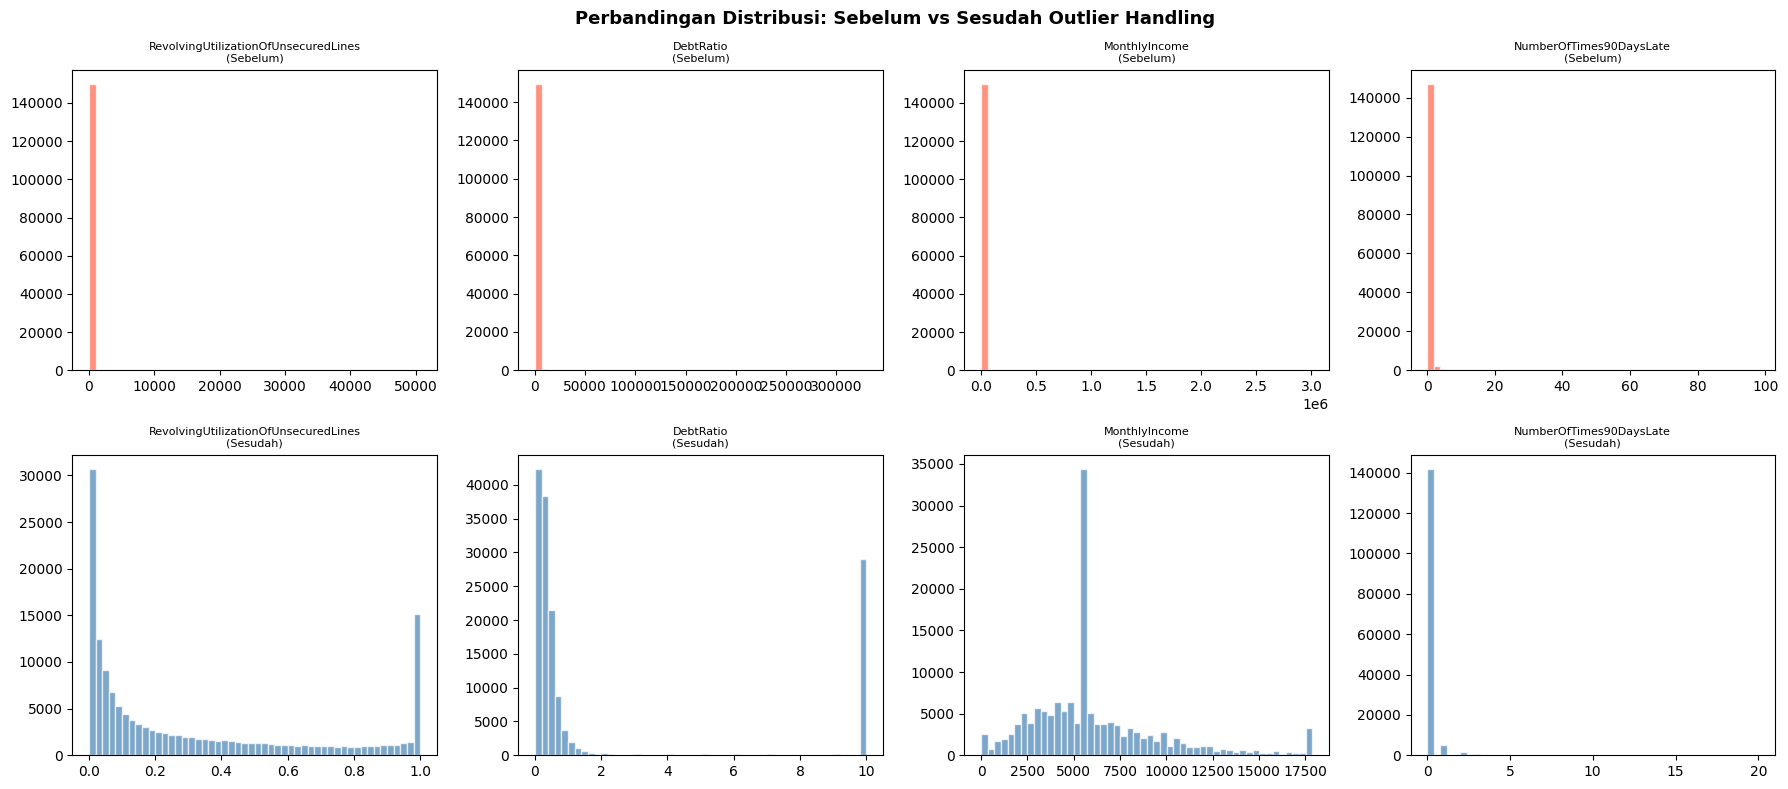

 RINGKASAN OUTLIER HANDLING 
Shape awal  : (150000, 11)
Shape akhir : (150000, 11)
Data hilang : 0 baris (strategi capping, bukan dropping)


In [ ]:
# Visualisasi perbandingan sebelum vs sesudah outlier handling
check_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfTimes90DaysLate'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(check_cols):
    # Sebelum (dari df_raw)
    axes[0, i].hist(df_raw[col].dropna(), bins=50,
                    color='tomato', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{col}\n(Sebelum)', fontsize=8)

    # Sesudah
    axes[1, i].hist(df[col], bins=50,
                    color='steelblue', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'{col}\n(Sesudah)', fontsize=8)

plt.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Outlier Handling',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(" RINGKASAN OUTLIER HANDLING ")
print(f"Shape awal  : {df_raw.shape}")
print(f"Shape akhir : {df.shape}")
print(f"Data hilang : 0 baris (strategi capping, bukan dropping)")

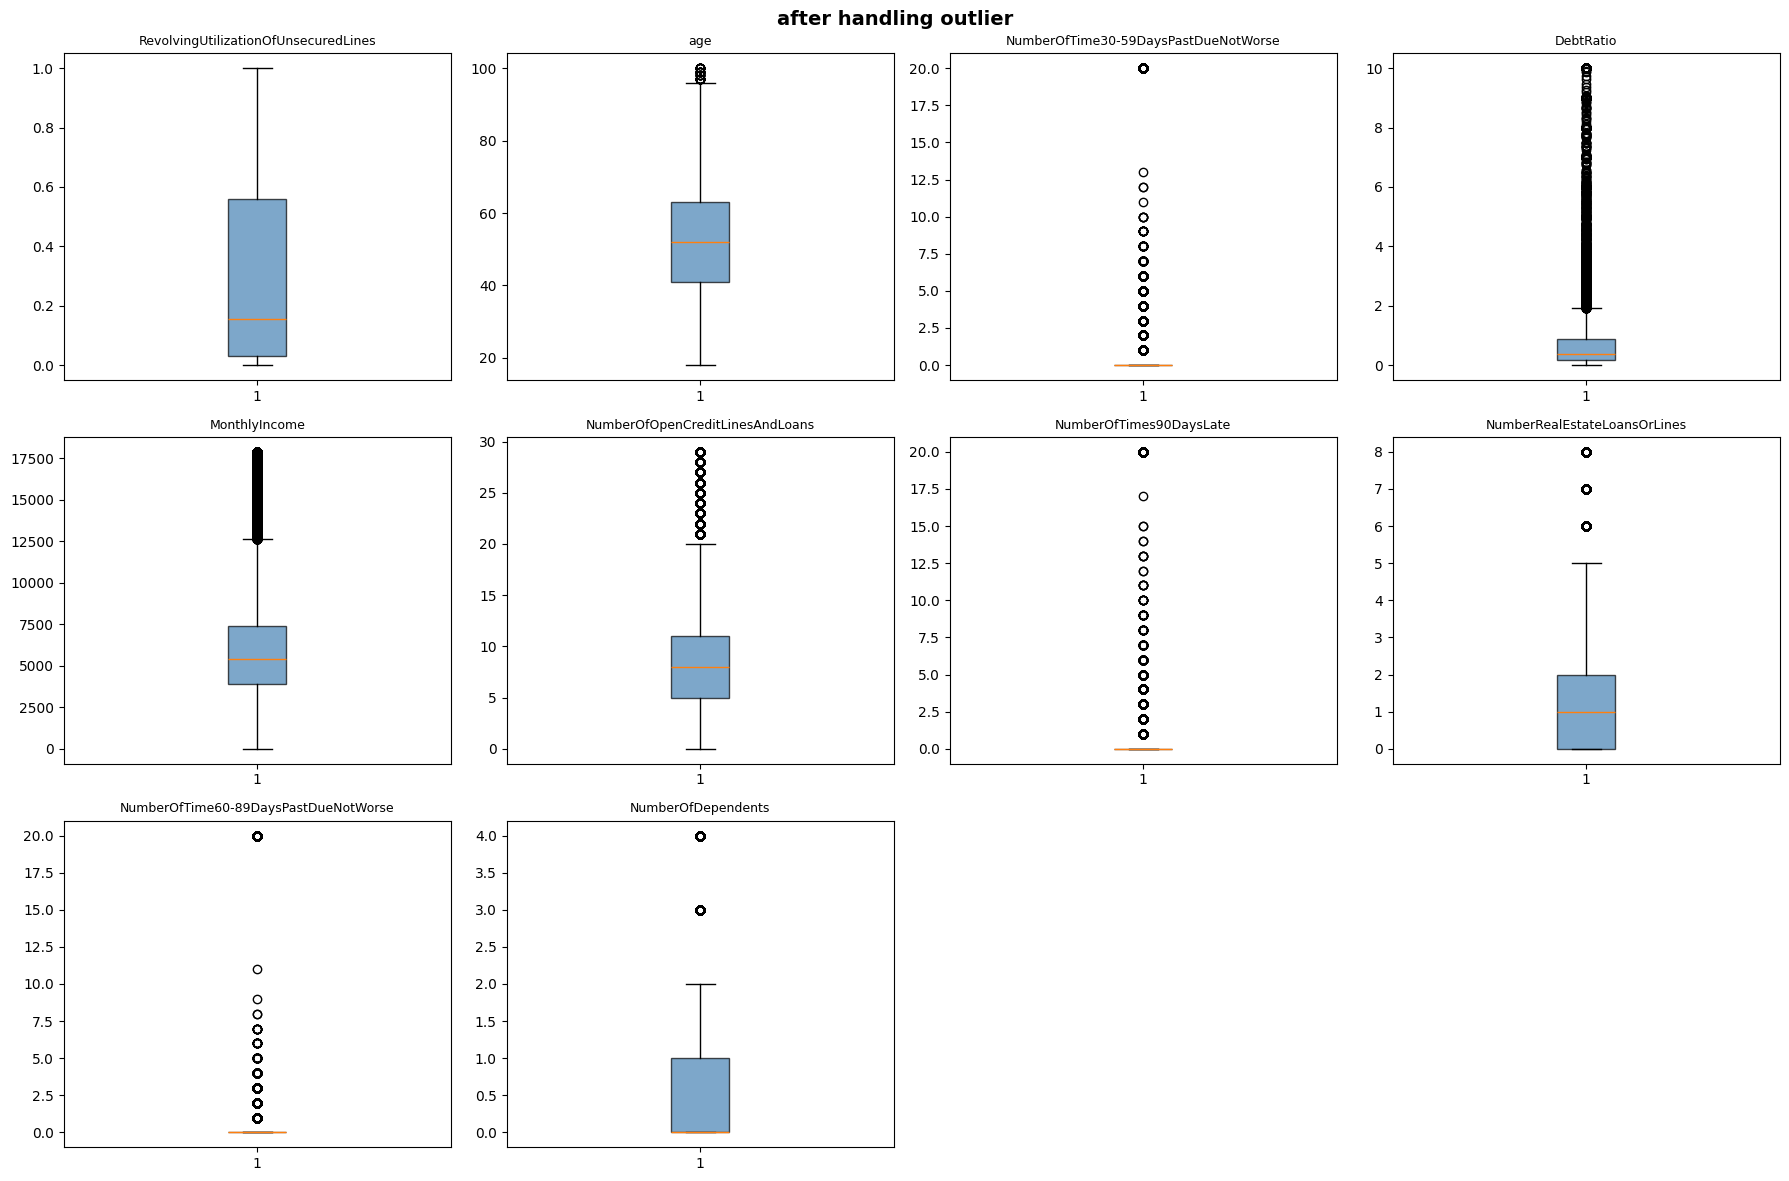

In [ ]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=9)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('after handling outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **3. Feature Engineering**

In [ ]:
# Total keterlambatan semua kategori
df['TotalLatePayments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

# Age group (binning usia)
df['AgeGroup'] = pd.cut(df['age'],
                         bins=[0, 30, 45, 60, 100],
                         labels=[0, 1, 2, 3]).astype(int)

# Income per dependent (pendapatan per tanggungan)
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

print(f"Total fitur sekarang: {df.shape[1]}")
df[['TotalLatePayments', 'AgeGroup', 'IncomePerDependent']].describe().round(2)

Total fitur sekarang: 14


,TotalLatePayments,AgeGroup,IncomePerDependent
count,150000.00,150000.00,150000.00
mean,0.51,1.89,4380.60
std,2.75,0.92,3019.61
min,0.00,0.00,0.00
25%,0.00,1.00,2161.00
50%,0.00,2.00,4000.00
75%,0.00,3.00,5400.00
max,60.00,3.00,17891.00


In [ ]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

=== HASIL SMOTE ===
Sebelum SMOTE: {0: np.int64(111979), 1: np.int64(8021)}
Setelah SMOTE: {0: np.int64(111979), 1: np.int64(111979)}


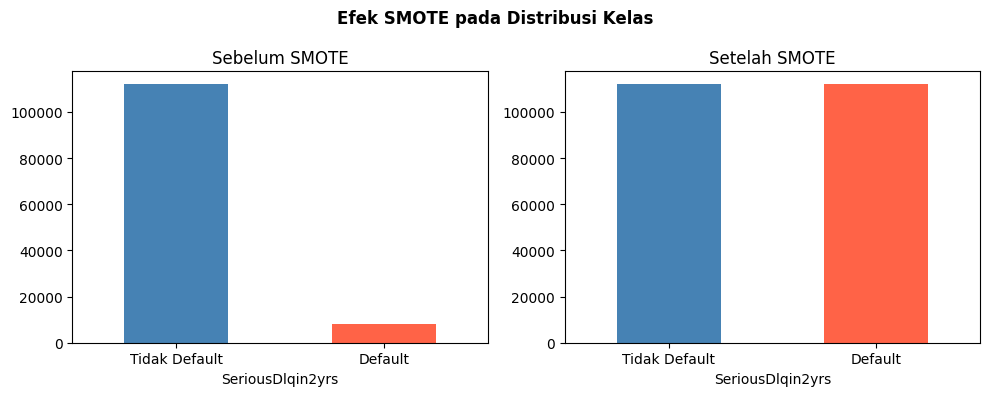

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("=== HASIL SMOTE ===")
print(f"Sebelum SMOTE: {dict(y_train.value_counts())}")
print(f"Setelah SMOTE: {dict(pd.Series(y_train_resampled).value_counts())}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], title='Sebelum SMOTE')
pd.Series(y_train_resampled).value_counts().plot(kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'], title='Setelah SMOTE')
axes[0].set_xticklabels(['Tidak Default', 'Default'], rotation=0)
axes[1].set_xticklabels(['Tidak Default', 'Default'], rotation=0)
plt.suptitle('Efek SMOTE pada Distribusi Kelas', fontweight='bold')
plt.tight_layout()
plt.show()

#4. Cluster Modeling

In [ ]:
# Fitur yang dipakai berdasarkan SHAP
cluster_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'TotalLatePayments',
    'age',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfTimes90DaysLate',
    'DebtRatio',
    'MonthlyIncome',
]

X_cluster = X[cluster_features].copy()

print("=" * 55)
print("  CEK DATA SEBELUM CLUSTERING")
print("=" * 55)
print(f"\n  Shape        : {X_cluster.shape}")
print(f"\n  Missing values:")
print(X_cluster.isnull().sum())
print(f"\n  Statistik deskriptif:")
print(X_cluster.describe().round(3))

  CEK DATA SEBELUM CLUSTERING

  Shape        : (150000, 8)

  Missing values:
RevolvingUtilizationOfUnsecuredLines    0
TotalLatePayments                       0
age                                     0
NumberOfOpenCreditLinesAndLoans         0
NumberRealEstateLoansOrLines            0
NumberOfTimes90DaysLate                 0
DebtRatio                               0
MonthlyIncome                           0
dtype: int64

  Statistik deskriptif:
       RevolvingUtilizationOfUnsecuredLines  TotalLatePayments         age  \
count                            150000.000         150000.000  150000.000   
mean                                  0.319              0.508      52.295   
std                                   0.349              2.752      14.770   
min                                   0.000              0.000      18.000   
25%                                   0.030              0.000      41.000   
50%                                   0.154              0.000      52.000   
7

# **5. Handling Outlier**

In [ ]:

X_cluster_clean = X_cluster.copy()

# Capping IQR per fitur — nilai di luar 1.5x IQR di-cap
for col in cluster_features:
    Q1  = X_cluster_clean[col].quantile(0.25)
    Q3  = X_cluster_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_cluster_clean[col] = X_cluster_clean[col].clip(lower, upper)

print("=" * 55)
print("  SETELAH HANDLING OUTLIER")
print("=" * 55)
print(X_cluster_clean.describe().round(3))

# Scaling
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_clean)

print(f"   Shape: {X_cluster_scaled.shape}")

  SETELAH HANDLING OUTLIER
       RevolvingUtilizationOfUnsecuredLines  TotalLatePayments         age  \
count                            150000.000           150000.0  150000.000   
mean                                  0.319                0.0      52.294   
std                                   0.349                0.0      14.768   
min                                   0.000                0.0      18.000   
25%                                   0.030                0.0      41.000   
50%                                   0.154                0.0      52.000   
75%                                   0.559                0.0      63.000   
max                                   1.000                0.0      96.000   

       NumberOfOpenCreditLinesAndLoans  NumberRealEstateLoansOrLines  \
count                       150000.000                    150000.000   
mean                             8.328                         1.002   
std                              4.737                

note: fitur TotalLatePayments & NumberOfTimes90DaysLate dibuang karena tidak ada variasi sama sekali setelah capping, tidak berguna untuk membedakan cluster

In [ ]:
cluster_features_final = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'DebtRatio',
    'MonthlyIncome',
]

X_cluster_clean2 = X[cluster_features_final].copy()

# Capping percentile 99 — lebih aman untuk fitur skewed
for col in cluster_features_final:
    upper = X_cluster_clean2[col].quantile(0.99)
    lower = X_cluster_clean2[col].quantile(0.01)
    X_cluster_clean2[col] = X_cluster_clean2[col].clip(lower, upper)

# Scaling
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster_clean2)

print("=" * 55)
print("  DATA FINAL UNTUK CLUSTERING")
print("=" * 55)
print(f"  Fitur yang dipakai : {cluster_features_final}")
print(f"  Shape              : {X_cluster_scaled.shape}")
print(f"\n  Statistik setelah capping:")
print(pd.DataFrame(X_cluster_clean2, columns=cluster_features_final).describe().round(3))


  DATA FINAL UNTUK CLUSTERING
  Fitur yang dipakai : ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'DebtRatio', 'MonthlyIncome']
  Shape              : (150000, 6)

  Statistik setelah capping:
       RevolvingUtilizationOfUnsecuredLines         age  \
count                            150000.000  150000.000   
mean                                  0.319      52.279   
std                                   0.349      14.668   
min                                   0.000      24.000   
25%                                   0.030      41.000   
50%                                   0.154      52.000   
75%                                   0.559      63.000   
max                                   1.000      87.000   

       NumberOfOpenCreditLinesAndLoans  NumberRealEstateLoansOrLines  \
count                       150000.000                    150000.000   
mean                             8.404                       

# **6. Visualization**

  K=2 | Inertia: 724,885 | Silhouette: 0.1866
  K=3 | Inertia: 590,978 | Silhouette: 0.2347
  K=4 | Inertia: 501,268 | Silhouette: 0.2305
  K=5 | Inertia: 451,392 | Silhouette: 0.2088
  K=6 | Inertia: 409,916 | Silhouette: 0.2148
  K=7 | Inertia: 384,720 | Silhouette: 0.2273
  K=8 | Inertia: 361,204 | Silhouette: 0.2298


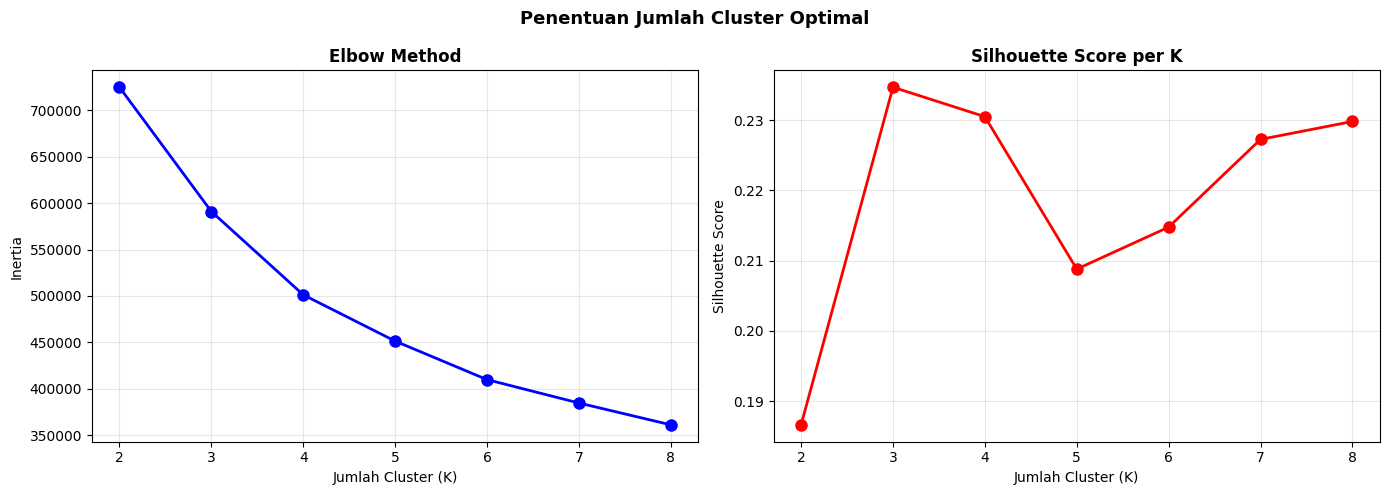

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias        = []
silhouette_scores = []
K_range         = range(2, 9)


for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_cluster_scaled, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(sil)
    print(f"  K={k} | Inertia: {kmeans.inertia_:,.0f} | Silhouette: {sil:.4f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [ ]:
# K-Means
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_cluster_scaled)

sil = silhouette_score(X_cluster_scaled, labels_kmeans, sample_size=10000, random_state=42)
db  = davies_bouldin_score(X_cluster_scaled, labels_kmeans)
ch  = calinski_harabasz_score(X_cluster_scaled, labels_kmeans)

print("── K-Means ──")
print(f"   Silhouette       : {sil:.4f}")
print(f"   Davies-Bouldin   : {db:.4f}")
print(f"   Calinski-Harabasz: {ch:.2f}")

── K-Means ──
   Silhouette       : 0.2347
   Davies-Bouldin   : 1.5724
   Calinski-Harabasz: 39217.02


In [ ]:
# Agglomerative sampel 10K
import numpy as np

np.random.seed(42)
idx      = np.random.choice(len(X_cluster_scaled), size=10000, replace=False)
X_sample = X_cluster_scaled[idx]

agglo = AgglomerativeClustering(n_clusters=OPTIMAL_K)
labels_agglo_sample = agglo.fit_predict(X_sample)

sil = silhouette_score(X_sample, labels_agglo_sample)
db  = davies_bouldin_score(X_sample, labels_agglo_sample)
ch  = calinski_harabasz_score(X_sample, labels_agglo_sample)

print("── Agglomerative (sampel 10K) ──")
print(f"   Silhouette       : {sil:.4f}")
print(f"   Davies-Bouldin   : {db:.4f}")
print(f"   Calinski-Harabasz: {ch:.2f}")

── Agglomerative (sampel 10K) ──
   Silhouette       : 0.2185
   Davies-Bouldin   : 1.6580
   Calinski-Harabasz: 2410.37


In [ ]:
# DBSCAN sampel 10K
dbscan = DBSCAN(eps=0.8, min_samples=50, n_jobs=-1)
labels_dbscan_sample = dbscan.fit_predict(X_sample)

n_clusters = len(set(labels_dbscan_sample)) - (1 if -1 in labels_dbscan_sample else 0)
n_noise    = list(labels_dbscan_sample).count(-1)

print("── DBSCAN (sampel 10K) ──")
print(f"   Jumlah cluster   : {n_clusters}")
print(f"   Noise points     : {n_noise}")

if n_clusters > 1:
    sil = silhouette_score(X_sample, labels_dbscan_sample)
    db  = davies_bouldin_score(X_sample, labels_dbscan_sample)
    ch  = calinski_harabasz_score(X_sample, labels_dbscan_sample)
    print(f"   Silhouette       : {sil:.4f}")
    print(f"   Davies-Bouldin   : {db:.4f}")
    print(f"   Calinski-Harabasz: {ch:.2f}")

── DBSCAN (sampel 10K) ──
   Jumlah cluster   : 7
   Noise points     : 2802
   Silhouette       : 0.0016
   Davies-Bouldin   : 2.3251
   Calinski-Harabasz: 678.97


  PROFIL TIAP CLUSTER
Cluster                                        0           1           2
RevolvingUtilizationOfUnsecuredLines      0.3970      0.2710      0.2420
age                                      49.0340     55.5510     54.7810
NumberOfOpenCreditLinesAndLoans           6.0390      7.5110     12.1170
NumberRealEstateLoansOrLines              0.4610      0.9030      1.7630
DebtRatio                                 0.3330      9.9180      0.4590
MonthlyIncome                          4381.6530   4992.4850   8972.7390
Default Rate                              0.0848      0.0551      0.0493
Jumlah Nasabah                        69252.0000  29536.0000  51212.0000


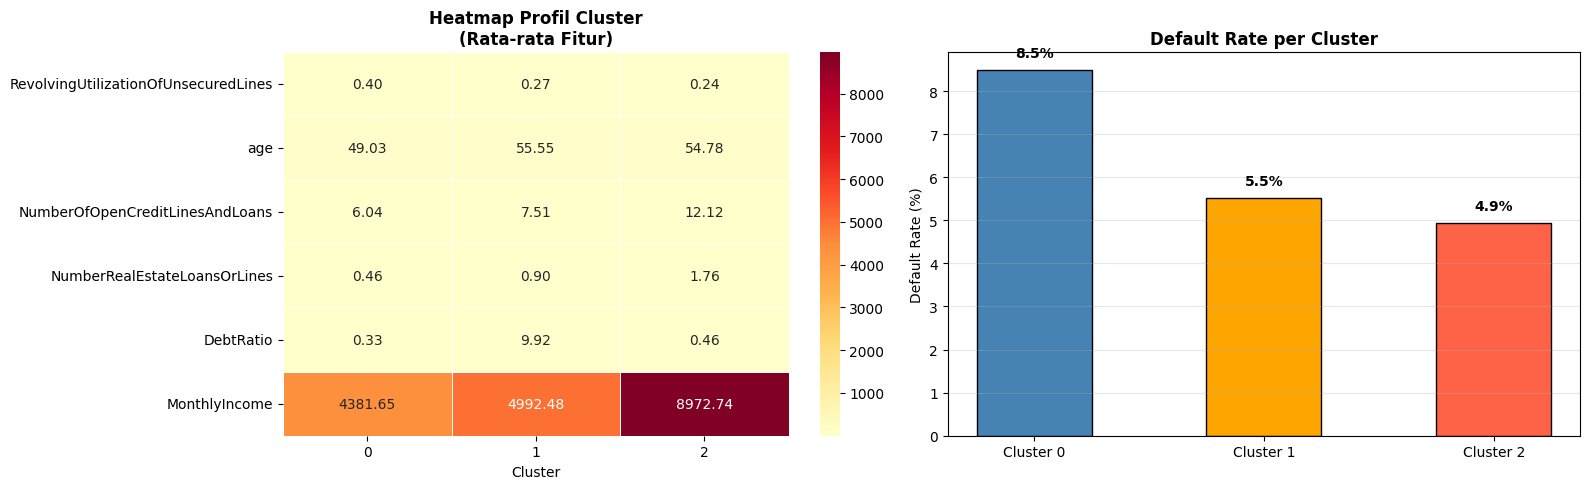

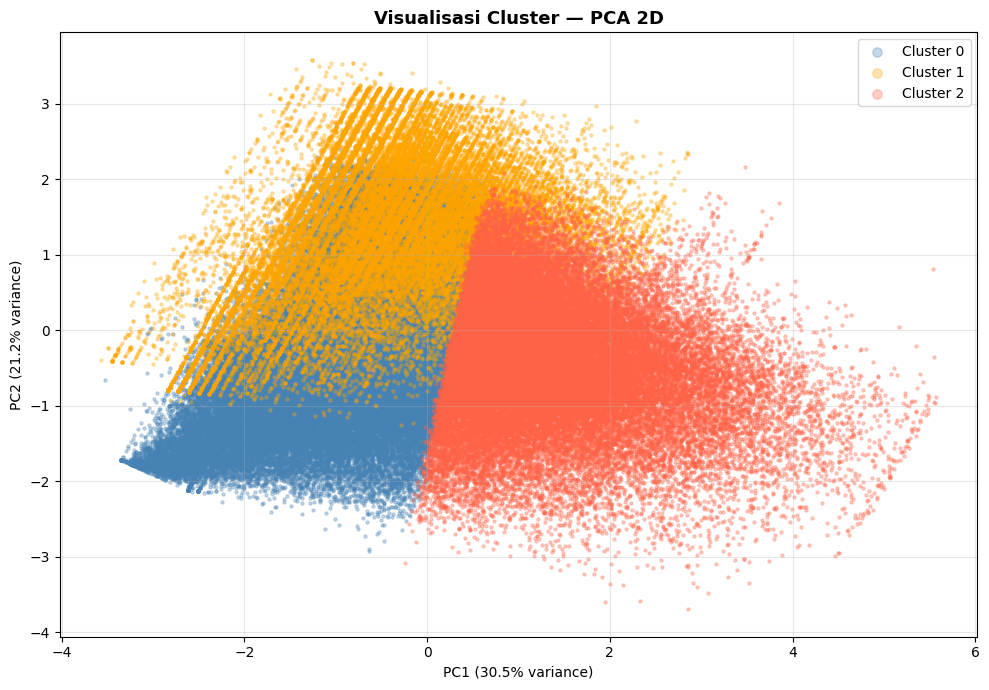


Profiling cluster selesai

  Jumlah nasabah per cluster:
    Cluster 0: 69,252 nasabah (46.2%)
    Cluster 1: 29,536 nasabah (19.7%)
    Cluster 2: 51,212 nasabah (34.1%)


In [ ]:
X_cluster_profil = X_cluster_clean2.copy()
X_cluster_profil['Cluster'] = labels_kmeans
X_cluster_profil['SeriousDlqin2yrs'] = y.values

# Profil rata-rata tiap cluster
profil = X_cluster_profil.groupby('Cluster')[cluster_features_final].mean().round(3)
default_rate = X_cluster_profil.groupby('Cluster')['SeriousDlqin2yrs'].mean().round(4)
cluster_size = X_cluster_profil.groupby('Cluster').size()

profil['Default Rate'] = default_rate
profil['Jumlah Nasabah'] = cluster_size

print("=" * 70)
print("  PROFIL TIAP CLUSTER")
print("=" * 70)
print(profil.T.to_string())

#  Heatmap profil cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    profil[cluster_features_final].T,
    annot=True, fmt='.2f', cmap='YlOrRd',
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Heatmap Profil Cluster\n(Rata-rata Fitur)', fontweight='bold')
axes[0].set_xlabel('Cluster')

#  Bar chart default rate per cluster
colors = ['steelblue', 'orange', 'tomato']
bars = axes[1].bar(
    [f'Cluster {i}' for i in profil.index],
    profil['Default Rate'] * 100,
    color=colors, edgecolor='black', width=0.5
)
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_title('Default Rate per Cluster', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, profil['Default Rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_profil.png', dpi=150, bbox_inches='tight')
plt.show()

#  PCA 2D Visualisasi
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
colors_pca = ['steelblue', 'orange', 'tomato']
for i, color in enumerate(colors_pca):
    mask = labels_kmeans == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=f'Cluster {i}',
               alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Visualisasi Cluster — PCA 2D', fontweight='bold', fontsize=13)
ax.legend(markerscale=3, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nProfiling cluster selesai")
print(f"\n  Jumlah nasabah per cluster:")
for i, n in cluster_size.items():
    print(f"    Cluster {i}: {n:,} nasabah ({n/len(X_cluster_profil)*100:.1f}%)")

In [ ]:
# Label otomatis berdasarkan default rate
dr = X_cluster_profil.groupby('Cluster')['SeriousDlqin2yrs'].mean()
rank = dr.rank(ascending=False).astype(int)
risk_map = {1: 'Berisiko Tinggi', 2: 'Berisiko Menengah', 3: 'Berisiko Rendah'}
cluster_labels = {c: risk_map[r] for c, r in rank.items()}

X_cluster_profil['Cluster Label'] = X_cluster_profil['Cluster'].map(cluster_labels)

print("=" * 60)
print("  RINGKASAN FINAL CLUSTERING")
print("=" * 60)
for i, label in cluster_labels.items():
    n     = cluster_size[i]
    dr    = profil.loc[i, 'Default Rate'] * 100
    inc   = profil.loc[i, 'MonthlyIncome']
    print(f"\n  Cluster {i} — {label}")
    print(f"    Jumlah nasabah : {n:,} ({n/len(X_cluster_profil)*100:.1f}%)")
    print(f"    Default rate   : {dr:.1f}%")
    print(f"    Monthly income : ${inc:,.0f}")

  RINGKASAN FINAL CLUSTERING

  Cluster 0 — Berisiko Tinggi
    Jumlah nasabah : 69,252 (46.2%)
    Default rate   : 8.5%
    Monthly income : $4,382

  Cluster 1 — Berisiko Menengah
    Jumlah nasabah : 29,536 (19.7%)
    Default rate   : 5.5%
    Monthly income : $4,992

  Cluster 2 — Berisiko Rendah
    Jumlah nasabah : 51,212 (34.1%)
    Default rate   : 4.9%
    Monthly income : $8,973


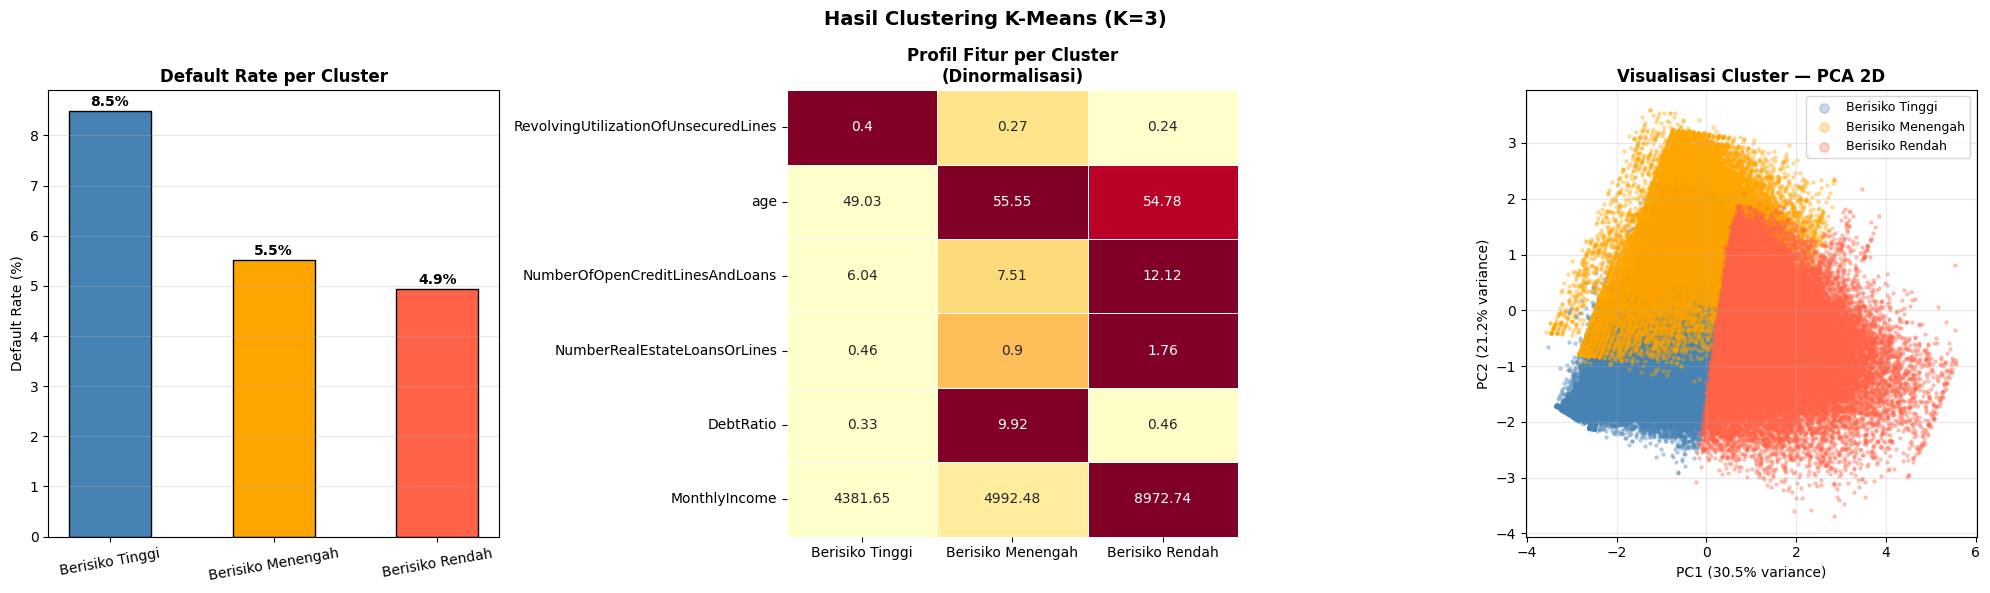

In [ ]:
colors = ['steelblue', 'orange', 'tomato']
short_labels = ['Berisiko Tinggi', 'Berisiko Menengah', 'Berisiko Rendah']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#  1. Default Rate per Cluster
bars = axes[0].bar(
    short_labels,
    [profil.loc[i, 'Default Rate'] * 100 for i in range(3)],
    color=colors, edgecolor='black', width=0.5
)
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_title('Default Rate per Cluster', fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for bar, val in zip(bars, [profil.loc[i, 'Default Rate'] * 100 for i in range(3)]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_xticklabels(short_labels, rotation=10)

#  2. Heatmap Profil Cluster
profil_plot = profil[cluster_features_final].copy()
profil_plot.index = short_labels
profil_normalized = (profil_plot - profil_plot.min()) / (profil_plot.max() - profil_plot.min())
sns.heatmap(profil_normalized.T, annot=profil_plot.T.round(2),
            fmt='g', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar=False)
axes[1].set_title('Profil Fitur per Cluster\n(Dinormalisasi)', fontweight='bold')
axes[1].set_xlabel('')

#  3. PCA Scatter
for i, color in enumerate(colors):
    mask = labels_kmeans == i
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=short_labels[i],
                    alpha=0.3, s=5)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[2].set_title('Visualisasi Cluster — PCA 2D', fontweight='bold')
axes[2].legend(0.markerscale=3, fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle('Hasil Clustering K-Means (K=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_final.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import joblib
import json
from google.colab import files

joblib.dump(kmeans,         'kmeans_final.pkl')
joblib.dump(scaler_cluster, 'scaler_cluster.pkl')

with open('cluster_metadata.json', 'w') as f:
    json.dump({
        'algorithm'       : 'K-Means',
        'n_clusters'      : 3,
        'features'        : cluster_features_final,
        'silhouette_score': round(float(silhouette_score(X_cluster_scaled, labels_kmeans, sample_size=10000, random_state=42)), 4),
        'cluster_labels'  : cluster_labels,
        'default_rate'    : {'0': 0.0848, '1': 0.0551, '2': 0.0493}
    }, f, indent=4)


files.download('kmeans_final.pkl')
files.download('scaler_cluster.pkl')
files.download('cluster_metadata.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
shutil.copy(os.path.join(path, 'cs-training.csv'), 'cs-training.csv')

from google.colab import files
files.download('cs-training.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **7. Kesimpulan**

Penelitian ini berhasil membangun sistem segmentasi nasabah berbasis K-Means clustering menggunakan dataset Give Me Some Credit (150.000 record). Berikut kesimpulan utama:

### 7.1 Pemilihan K Optimal
Nilai K=3 dipilih berdasarkan **Silhouette Score tertinggi (0,2347)** dari evaluasi K=2 hingga K=8:

| K | Inertia | Silhouette |
|---|---|---|
| 2 | 724.885 | 0,1866 |
| **3** | **590.978** | **0,2347** ← optimal |
| 4 | 501.268 | 0,2305 |
| 5 | 451.392 | 0,2088 |

### 7.2 Profil Segmen Nasabah

| Segmen | Jumlah | Proporsi | Default Rate | Income Rata-rata |
|---|---|---|---|---|
| Berisiko Tinggi (Cluster 0) | 69.252 | 46,2% | 8,5% | $4.382 |
| Berisiko Menengah (Cluster 1) | 29.536 | 19,7% | 5,5% | $4.992 |
| Berisiko Rendah (Cluster 2) | 51.212 | 34,1% | 4,9% | $8.973 |

> Label ditetapkan otomatis berdasarkan `default_rate` per cluster.

### 7.3 Perbandingan Metode

| Metode | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|---|---|---|---|
| **K-Means (K=3)** | **0,2347** | **1,5724** | **39.217** |
| Agglomerative | 0,2185 | 1,6580 | 2.410 |
| DBSCAN | 0,0016 | 2,3251 | 679 |

K-Means unggul di semua metrik. DBSCAN menghasilkan 7 cluster dengan noise 2.802 titik (28%) dan Silhouette sangat rendah (0,0016) — tidak valid untuk segmentasi nasabah.

### 7.4 Implikasi Bisnis
- **Berisiko Tinggi**: Limit kredit minimum, wajib jaminan, verifikasi pendapatan ulang
- **Berisiko Menengah**: Kredit standar dengan pemantauan bulanan
- **Berisiko Rendah**: Kandidat produk premium, peningkatan limit, program loyalitas

### 7.5 Limitasi
- Silhouette Score 0,2347 tergolong moderat — karakteristik umum data finansial high-dimensional
- DBSCAN tidak cocok untuk data tabular berdimensi tinggi
- Segmentasi bersifat deskriptif, perlu dikombinasikan dengan model prediktif